# Day 2:  <font color = "red">**Structure → Property Challenge**</font>

Can local image structure predict the local EELS response?

For each location, we have:

**Image patch → EELS spectrum → Scalarizer**

Your task is to:

1. Build a <font color = "purple">**descriptor**</font> for the image patch.
2. Use a <font color = "purple">**regressor**</font> to predict a scalarizer or the full spectrum.
3. Compare methods by:
   - predictive power
   - complexity
   - explainability

<font color = "green">**Goal**</font>

> Find the simplest explainable descriptor that predicts the EELS response well.

## <font color = "purple">**1.**</font> Explore the Dataset

Each spatial location contains:

- one image intensity value
- one full EELS spectrum

The same position in the image corresponds to the same position in the EELS spectrum image.

Let's look at one dataset.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kbarakati/athena_camm_hackathon/blob/k4my4r/docs/day_17_18092026/notebook.ipynb)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
import os
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [ ]:
# !gdown --fuzzy 1FKmlRTRDImQS91V4YQjcQHoJU19X6P_6

In [ ]:
file_name = "/content/Plasmonic_sets_hackathon.npy"

raw = np.load(
    file_name,
    allow_pickle=True
)

loadedfile = raw.tolist()
print("keys:", loadedfile.keys())

keys: dict_keys(['0', '1', '2', '3'])


In [ ]:
# Choose dataset
data = loadedfile["2"]

image = data["image"]
spectra = data["spectrum image"]
energy = data["energy axis"]

H, W = image.shape

print(image.shape)
print(spectra.shape)
print(energy.shape)

(33, 63)
(33, 63, 4322)
(4322,)


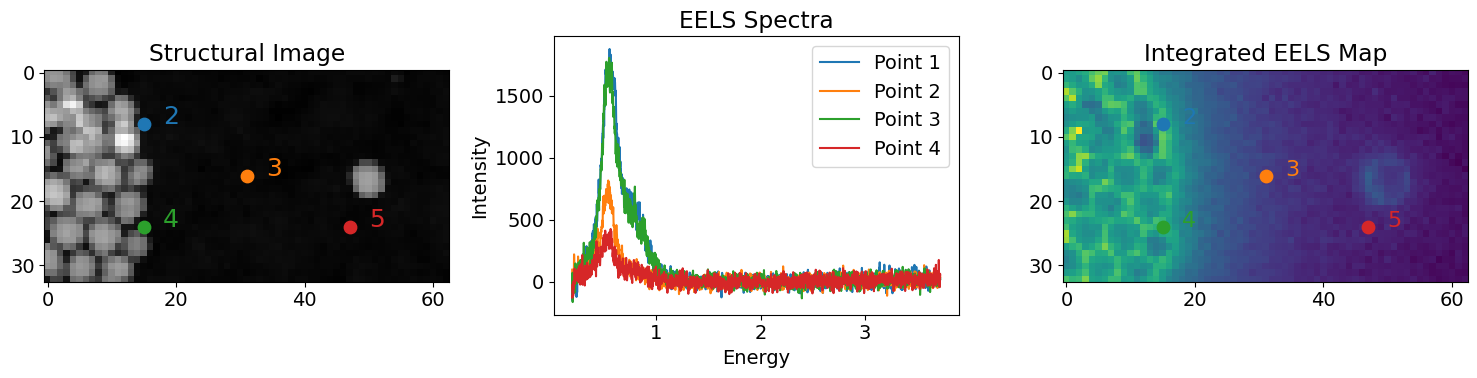

In [ ]:
# Example locations
positions = [
    (H // 4, W // 4),
    (H // 2, W // 2),
    (3 * H // 4, W // 4),
    (3 * H // 4, 3 * W // 4),
]

colors = ["C0", "C1", "C2", "C3"]

# Integrated EELS map
eels_map = spectra.sum(axis=2)

plt.rcParams.update({"font.size": 14})

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Structural image
ax[0].imshow(image, cmap="gray")
ax[0].set_title("Structural Image")

# Spectra
for i, ((y, x), color) in enumerate(zip(positions, colors)):

    ax[0].scatter(x, y, s=80, color=color)
    ax[0].text(x + 3, y, str(i + 2), color=color, fontsize=18)

    ax[1].plot(
        energy,
        spectra[y, x],
        color=color,
        label=f"Point {i + 1}"
    )

    ax[2].scatter(x, y, s=80, color=color)
    ax[2].text(x + 3, y, str(i + 2), color=color, fontsize=16)

ax[1].set_title("EELS Spectra")
ax[1].set_xlabel("Energy")
ax[1].set_ylabel("Intensity")
ax[1].legend()

# EELS map
ax[2].imshow(eels_map)
ax[2].set_title("Integrated EELS Map")

plt.tight_layout()
plt.show()

## <font color = "purple">**2.**</font> Define a Scalarizer

Each EELS spectrum can be reduced to a **single target value** called a scalarizer.

For example, the spectral intensity within an energy window:

$$
S(x,y)=\int_{E_1}^{E_2} I(x,y,E)\,dE
$$

where \(E_1\) and \(E_2\) define the spectral region of interest.

Other possible scalarizers include:

- peak intensity
- peak position
- peak area
- peak ratio

## <font color = "purple">**3.**</font> Choose a Spectral Region

Before defining the scalarizer, inspect the EELS spectrum and choose an energy range containing a feature of interest.

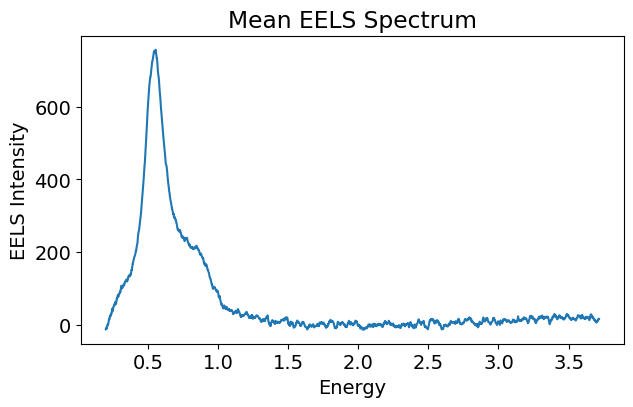

In [ ]:
# Mean spectrum over the whole image
mean_spectrum = spectra.mean(axis=(0, 1))

plt.figure(figsize=(7, 4))

plt.plot(energy, mean_spectrum)

plt.xlabel("Energy")
plt.ylabel("EELS Intensity")
plt.title("Mean EELS Spectrum")

plt.show()

## <font color = "purple">**4.**</font> Calculate the Scalarizer

We integrate the EELS intensity inside the selected energy window to obtain one target value at each spatial location.

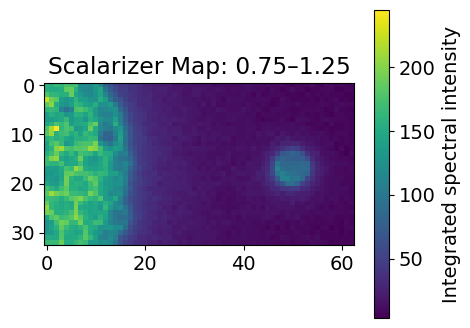

In [ ]:
# Choose an energy range
E1 = 0.75
E2 = 1.25

mask = (energy >= E1) & (energy <= E2)

scalarizer_map = np.trapezoid(
    spectra[:, :, mask],
    energy[mask],
    axis=2
)

plt.figure(figsize=(5, 4))
plt.imshow(scalarizer_map)
plt.colorbar(label="Integrated spectral intensity")
plt.title(f"Scalarizer Map: {E1}–{E2}")
plt.show()

## <font color = "purple">**5.**</font> Create Patch–Spectrum–Scalarizer Pairs

For each location we collect:

**Image patch → EELS spectrum → Scalarizer**

The spectrum and scalarizer correspond to the center pixel of the patch.

In [ ]:
PATCH_SIZE = 12
half = PATCH_SIZE // 2

patches = []
targets = []

for y in range(half, H - half):
    for x in range(half, W - half):

        patch = image[y-half:y+half+1, x-half:x+half+1]

        patches.append(patch)
        targets.append(scalarizer_map[y, x])

patches = np.array(patches)
targets = np.array(targets)

print(patches)
print("Patches:", patches.shape)
print("Targets:", targets.shape)

[[[ 0.01586698  0.01690626  0.01640257 ... -0.00242749 -0.00753479
   -0.00696184]
  [ 0.01550147  0.01782062  0.01733903 ...  0.00887009 -0.00633498
   -0.00712011]
  [ 0.01228913  0.01428573  0.01334882 ...  0.01123953 -0.00544918
   -0.00679734]
  ...
  [-0.0035459  -0.00240332  0.01123149 ...  0.01282927  0.03162044
    0.03453457]
  [ 0.00855816  0.00339349  0.01237345 ...  0.01240731  0.03162554
    0.03321829]
  [ 0.01671899  0.00245779  0.00415991 ...  0.00685998  0.02032228
    0.0252854 ]]

 [[ 0.01690626  0.01640257  0.01229225 ... -0.00753479 -0.00696184
   -0.00681391]
  [ 0.01782062  0.01733903  0.01503665 ... -0.00633498 -0.00712011
   -0.00700112]
  [ 0.01428573  0.01334882  0.01475397 ... -0.00544918 -0.00679734
   -0.00598955]
  ...
  [-0.00240332  0.01123149  0.01320753 ...  0.03162044  0.03453457
    0.03103224]
  [ 0.00339349  0.01237345  0.01385883 ...  0.03162554  0.03321829
    0.02890135]
  [ 0.00245779  0.00415991  0.01155656 ...  0.02032228  0.0252854
    0.0

## <font color = "purple">**6.**</font> Look at Example Pairs

Each patch has one target scalarizer value.

Can you see structural differences between low and high target values?

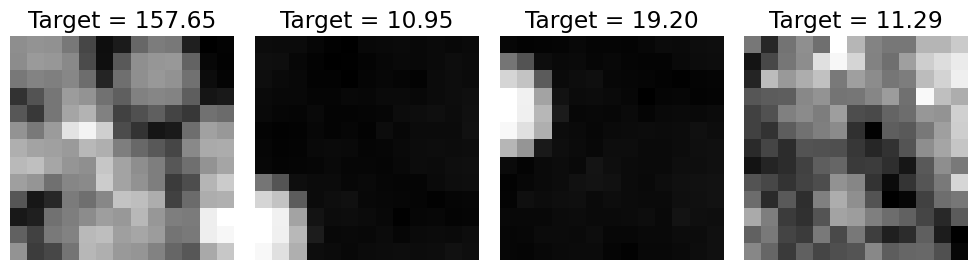

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(10, 3))

ids = np.linspace(0, len(patches) - 1, 4, dtype=int)

for i, idx in enumerate(ids):
    ax[i].imshow(patches[idx], cmap="gray")
    ax[i].set_title(f"Target = {targets[idx]:.2f}")
    ax[i].axis("off")

plt.tight_layout()
plt.show()

## The Challenge

You will design two parts of the prediction pipeline:

**Image Patch → Descriptor → Regressor → EELS Scalarizer**

### Your goal

Find a combination with:

- high predictive power
- low complexity
- good explainability

You can change:

1. the **descriptor** — how the image patch is represented
2. the **regressor** — how the descriptor is mapped to the EELS property

Try different combinations and compare their performance.

## <font color = "purple">**7.**</font> Define Your Descriptor and Regressor

Change only the code inside the marked sections.

The descriptor converts an image patch into features.

The regressor learns how those features relate to the EELS scalarizer.

In [ ]:

import numpy as np
from skimage.feature import graycomatrix
from skimage import exposure, util
from skimage.feature import graycomatrix, graycoprops

def descriptor(patch):

    # ============================================================
    # YOUR CODE STARTS HERE
    # ============================================================

    levels = 4
    quantized_patch = np.digitize(patch, bins=np.linspace(image.min(), image.max(), levels)) - 1
    glcm = graycomatrix(quantized_patch, distances=[1], angles=[0, np.pi/2], levels=levels, symmetric=True, normed=True)
    homogeneity = graycoprops(glcm, 'homogeneity')
    contrast = graycoprops(glcm, 'contrast')
    features = [
        patch.mean(),
        patch.std(),
        patch.max() - patch.min(),
        #feature to discribe constrast within patch
        homogeneity.mean(),
        contrast.mean()
    ]
    # ============================================================
    # YOUR CODE ENDS HERE
    # ============================================================

    return features


def regressor():

    # ============================================================
    # YOUR CODE STARTS HERE
    # ============================================================

    # model = LinearRegression(),
    # model = Ridge(alpha=1.0),
    # model = KNeighborsRegressor(n_neighbors=8),
    model = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1)

    # ============================================================
    # YOUR CODE ENDS HERE
    # ============================================================

    return model

## <font color = "purple">**8.**</font> Run Your Pipeline

Now we test your descriptor–regressor combination.

The same train/test split is used each time so different combinations can be compared fairly.

In [ ]:
# Build descriptor matrix
X = np.array([descriptor(patch) for patch in patches])

# Same split for every experiment
X_train, X_test, y_train, y_test = train_test_split(
    X,
    targets,
    test_size=0.25,
    random_state=0
)

# Train
model = regressor()
model.fit(X_train, y_train)

# Predict
predictions = model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, predictions)

print("Regressor:", type(model).__name__)
print("Number of features:", X.shape[1])
print(f"R²: {r2:.3f}")

Regressor: RandomForestRegressor
Number of features: 5
R²: 0.973


## <font color = "purple">**9.**</font> Compare Prediction with Ground Truth

A good model should predict values close to the measured EELS scalarizer.

Points closer to the diagonal line indicate better agreement.

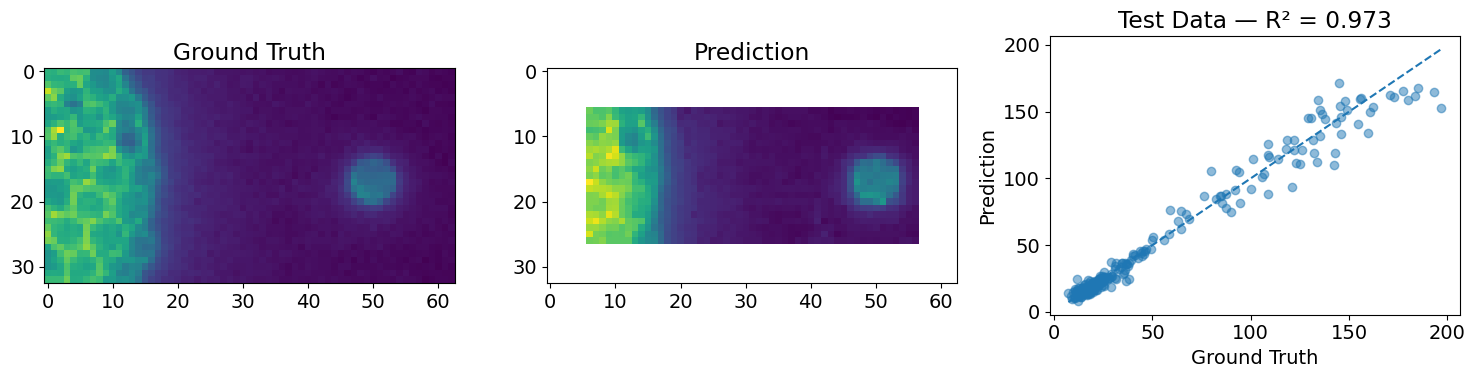

In [ ]:
# Size of valid prediction region
map_shape = (
    H - 2 * half,
    W - 2 * half
)

# Predicted values
predicted = model.predict(X).reshape(map_shape)

# Put predictions back into an image of the original size
prediction_map = np.full((H, W), np.nan)

prediction_map[
    half:H-half,
    half:W-half
] = predicted


fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].imshow(scalarizer_map)
ax[0].set_title("Ground Truth")

ax[1].imshow(prediction_map)
ax[1].set_title("Prediction")

# Test data
ax[2].scatter(y_test, predictions, alpha=0.5)

low = min(y_test.min(), predictions.min())
high = max(y_test.max(), predictions.max())

ax[2].plot([low, high], [low, high], "--")
ax[2].set_xlabel("Ground Truth")
ax[2].set_ylabel("Prediction")
ax[2].set_title(f"Test Data — R² = {r2:.3f}")

plt.tight_layout()
plt.show()

## <font color = "purple">**10.**</font> Compare Descriptor–Regressor Combinations

Test several descriptors and regressors.

Create a heatmap where:

- rows = descriptors
- columns = regressors
- color/value = test R²

Use the same train/test split for every combination.

### <font color = "red">**Goal**</font>

Identify which descriptor–regressor combinations give the strongest predictive performance.

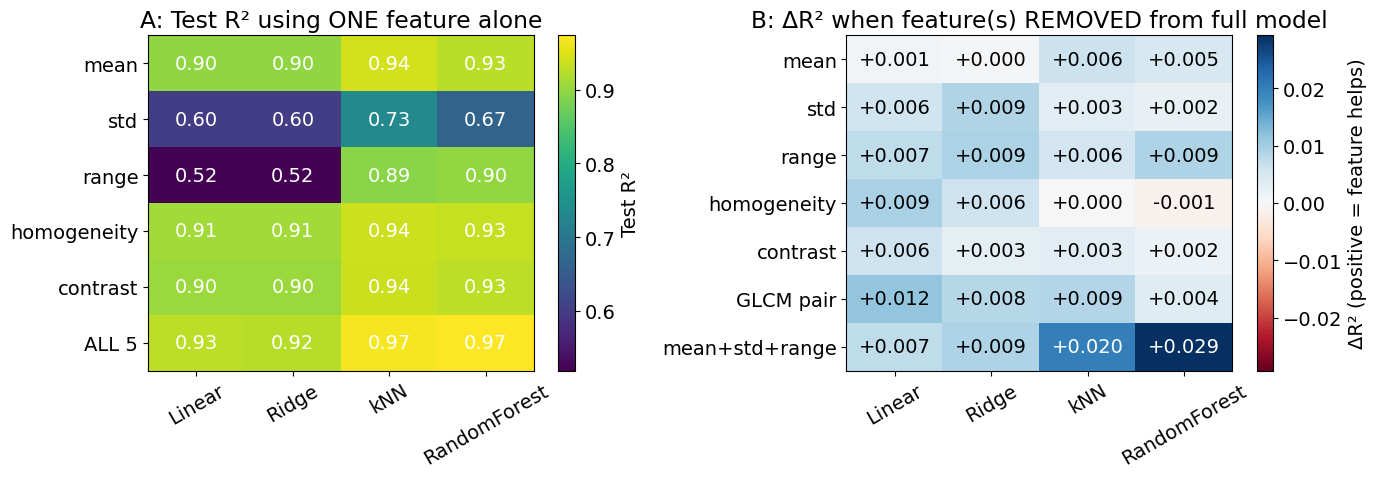

In [ ]:
# ============================================================
# YOUR CODE STARTS HERE
# ============================================================

feature_names = ["mean", "std", "range", "homogeneity", "contrast"]

regs = {
    "Linear": LinearRegression,
    "Ridge": lambda: Ridge(alpha=1.0),
    "kNN": lambda: KNeighborsRegressor(n_neighbors=10),
    "RandomForest": lambda: RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1),
}

# Build the descriptor matrix once, then select columns
X = np.array([descriptor(p) for p in patches])          # (N, 5)
tr, te = train_test_split(np.arange(len(X)), test_size=0.25, random_state=0)

def fit_score(make, cols):
    model = make_pipeline(StandardScaler(), make())      # scaling matters for kNN
    model.fit(X[tr][:, cols], targets[tr])
    return r2_score(targets[te], model.predict(X[te][:, cols]))

all_cols = list(range(X.shape[1]))
makers = list(regs.values())

# Full model
R_full = np.array([fit_score(mk, all_cols) for mk in makers])

# Panel A: each feature alone (+ full model as the last row)
R_single = np.array([[fit_score(mk, [f]) for mk in makers] for f in all_cols])
R_A = np.vstack([R_single, R_full])
rows_A = feature_names + ["ALL 5"]

# Panel B: drop-one / drop-group ΔR² = R²(all) - R²(all minus these features)
groups = {name: [i] for i, name in enumerate(feature_names)}
groups["GLCM pair"] = [3, 4]
groups["mean+std+range"] = [0, 1, 2]

R_B = np.array([
    [R_full[j] - fit_score(mk, [c for c in all_cols if c not in cols])
     for j, mk in enumerate(makers)]
    for cols in groups.values()
])
rows_B = list(groups.keys())

def annotate(ax, R, fmt="{:.2f}"):
    for i in range(R.shape[0]):
        for j in range(R.shape[1]):
            ax.text(j, i, fmt.format(R[i, j]), ha="center", va="center",
                    color="w" if abs(R[i, j]) > 0.5 * np.abs(R).max() else "k")

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

im0 = ax[0].imshow(R_A, cmap="viridis", aspect="auto")
ax[0].set_title("A: Test R² using ONE feature alone")
ax[0].set_yticks(range(len(rows_A))); ax[0].set_yticklabels(rows_A)
plt.colorbar(im0, ax=ax[0], label="Test R²")
annotate(ax[0], R_A)

lim = np.abs(R_B).max()
im1 = ax[1].imshow(R_B, cmap="RdBu", vmin=-lim, vmax=lim, aspect="auto")
ax[1].set_title("B: ΔR² when feature(s) REMOVED from full model")
ax[1].set_yticks(range(len(rows_B))); ax[1].set_yticklabels(rows_B)
plt.colorbar(im1, ax=ax[1], label="ΔR² (positive = feature helps)")
annotate(ax[1], R_B, "{:+.3f}")

for a in ax:
    a.set_xticks(range(len(regs))); a.set_xticklabels(regs.keys(), rotation=30)

plt.tight_layout()
plt.show()
# ============================================================
# YOUR CODE ENDS HERE
# ============================================================

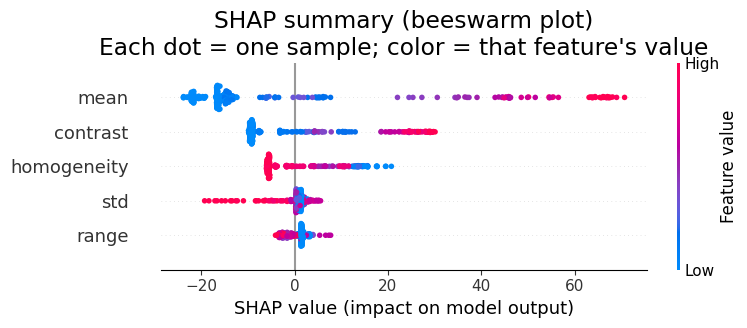

In [ ]:
import shap

feature_cols = ["mean", "std", "range", "homogeneity", "contrast"]
model = RandomForestRegressor(n_estimators=300, max_depth=6, random_state=42)
model.fit(X_train, y_train)
explainer = shap.Explainer(model, X_train, feature_names=feature_cols)
shap_values = explainer(X_test, check_additivity = False)

fig = plt.figure(figsize=(8, 5))
shap.plots.beeswarm(shap_values, show=False)
plt.title("SHAP summary (beeswarm plot)\nEach dot = one sample; color = that feature's value")
plt.tight_layout()
plt.show()

## <font color = "purple">**11.**</font> Best Model and Explainability

From the heatmap, identify the best descriptor–regressor combination.

Report:

- best descriptor
- best regressor
- number of descriptor features
- test R²

Then explain:

- What does the descriptor measure?
- Which structural features are important?
- Why might those features be related to the EELS response?

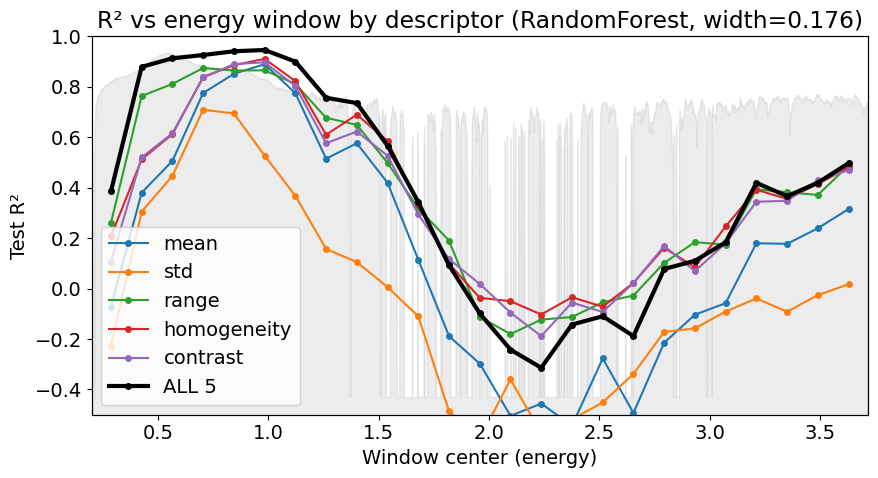

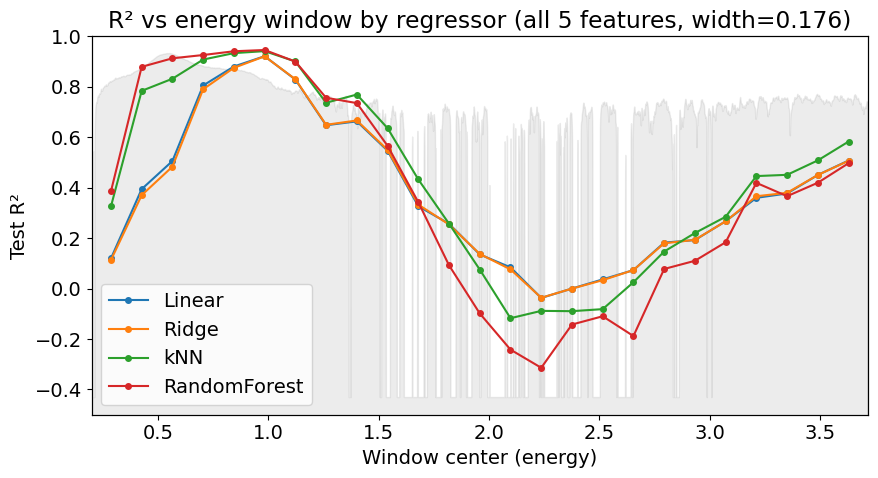


Best window (RandomForest, ALL 5): 0.896 to 1.07, R² = 0.946


In [ ]:
# ============================================================
# YOUR CODE STARTS HERE
# ============================================================
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# ---------------- settings ----------------
N_WINDOWS     = 25                                   # number of window positions
WIDTH         = (energy.max() - energy.min()) / 20   # window width, same units as `energy`
REF_REGRESSOR = "RandomForest"                              # regressor used in the descriptor plot
NORMALIZE     = False                                # True: divide scalarizer by total counts per pixel
# ------------------------------------------

feature_names = ["mean", "std", "range", "homogeneity", "contrast"]

regs = {
    "Linear": LinearRegression,
    "Ridge": lambda: Ridge(alpha=1.0),
    "kNN": lambda: KNeighborsRegressor(n_neighbors=10),
    "RandomForest": lambda: RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1),
}

# Descriptor matrix (image-only, so independent of the energy window)
X = np.array([descriptor(p) for p in patches])
tr, te = train_test_split(np.arange(len(X)), test_size=0.25, random_state=0)
Xtr, Xte = X[tr], X[te]

# Each feature alone, plus the full descriptor
feature_sets = {name: [i] for i, name in enumerate(feature_names)}
feature_sets["ALL 5"] = list(range(len(feature_names)))

valid = (slice(half, H - half), slice(half, W - half))   # same pixels/order as `patches`
total = spectra.sum(axis=2)[valid].ravel()

centers = np.linspace(energy.min() + WIDTH / 2, energy.max() - WIDTH / 2, N_WINDOWS)
R = np.full((N_WINDOWS, len(feature_sets), len(regs)), np.nan)   # [window, feature set, regressor]

for w, c in enumerate(centers):
    mask = (energy >= c - WIDTH / 2) & (energy <= c + WIDTH / 2)
    if mask.sum() < 2:
        continue
    s = np.trapezoid(spectra[:, :, mask], energy[mask], axis=2)
    y = s[valid].ravel()
    if NORMALIZE:
        y = y / (total + 1e-12)
    if np.std(y[tr]) == 0:
        continue
    for f, cols in enumerate(feature_sets.values()):
        for r, make in enumerate(regs.values()):
            m = make_pipeline(StandardScaler(), make()).fit(Xtr[:, cols], y[tr])
            R[w, f, r] = r2_score(y[te], m.predict(Xte[:, cols]))
    print(f"window {w+1}/{N_WINDOWS}  center={c:.3g}  done", end="\r")

# ---------------- plotting ----------------
mean_spectrum = spectra.mean(axis=(0, 1))
ymin = max(np.nanmin(R), -0.5)

def add_spectrum_backdrop(ax):
    """Gray mean spectrum (log scale) behind the curves, so peaks line up with R²."""
    ax2 = ax.twinx()
    ax2.fill_between(energy, np.clip(mean_spectrum, 1e-9, None), color="gray", alpha=0.15)
    ax2.set_yscale("log"); ax2.set_yticks([])
    ax.set_zorder(ax2.get_zorder() + 1); ax.patch.set_visible(False)

ref = list(regs).index(REF_REGRESSOR)
all5 = list(feature_sets).index("ALL 5")

# Plot 1: R² vs window position, one line per descriptor feature (fixed regressor)
fig, ax = plt.subplots(figsize=(9, 5))
add_spectrum_backdrop(ax)
for f, name in enumerate(feature_sets):
    ax.plot(centers, R[:, f, ref], marker="o", ms=4,
            lw=3 if name == "ALL 5" else 1.5,
            color="k" if name == "ALL 5" else None, label=name)
ax.set_xlabel("Window center (energy)"); ax.set_ylabel("Test R²")
ax.set_ylim(ymin, 1); ax.set_xlim(energy.min(), energy.max())
ax.set_title(f"R² vs energy window by descriptor ({REF_REGRESSOR}, width={WIDTH:.3g})")
ax.legend(); plt.tight_layout(); plt.show()

# Plot 2: R² vs window position, one line per regressor (all 5 features)
fig, ax = plt.subplots(figsize=(9, 5))
add_spectrum_backdrop(ax)
for r, name in enumerate(regs):
    ax.plot(centers, R[:, all5, r], marker="o", ms=4, label=name)
ax.set_xlabel("Window center (energy)"); ax.set_ylabel("Test R²")
ax.set_ylim(ymin, 1); ax.set_xlim(energy.min(), energy.max())
ax.set_title(f"R² vs energy window by regressor (all 5 features, width={WIDTH:.3g})")
ax.legend(); plt.tight_layout(); plt.show()

# Best window for the full descriptor + reference regressor
best = np.nanargmax(R[:, all5, ref])
print(f"\nBest window ({REF_REGRESSOR}, ALL 5): {centers[best]-WIDTH/2:.3g} to "
      f"{centers[best]+WIDTH/2:.3g}, R² = {R[best, all5, ref]:.3f}")
# ============================================================
# YOUR CODE ENDS HERE
# ============================================================

1071 evaluation pixels (803 train / 268 test), split=random


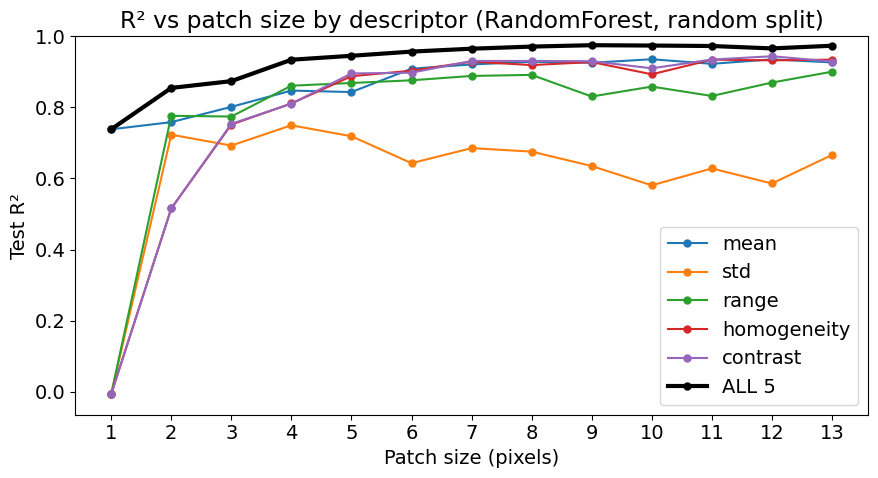

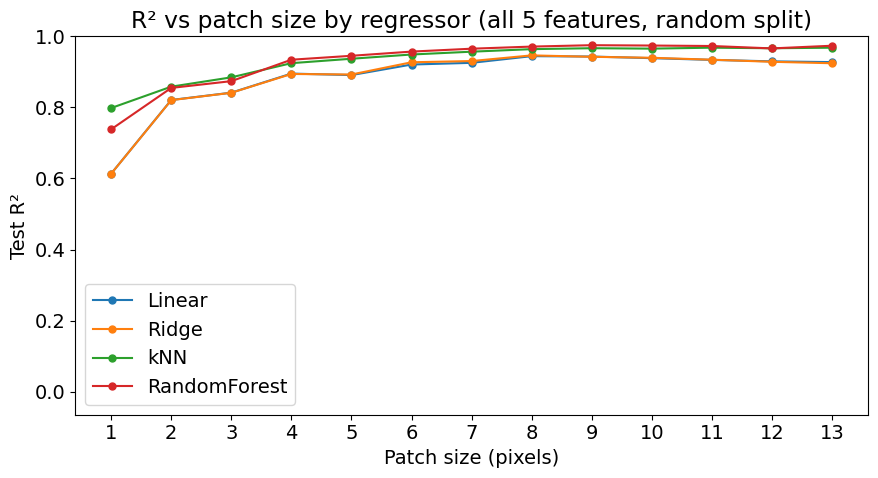


Best patch size (RandomForest, ALL 5): 9x9, R² = 0.975


In [ ]:
from numpy.lib.stride_tricks import sliding_window_view
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# ---------------- settings ----------------
PATCH_SIZES   = [1,2,3,4, 5,6, 7,8, 9,10, 11,12,13,14, 15,16,17,18,19,20, 21]   # odd sizes only
REF_REGRESSOR = "RandomForest"                    # regressor used in the descriptor plot
SPLIT         = "random"                   # "random" (challenge default) or "blocked"
# ------------------------------------------

feature_names = ["mean", "std", "range", "homogeneity", "contrast"]

regs = {
    "Linear": LinearRegression,
    "Ridge": lambda: Ridge(alpha=1.0),
    "kNN": lambda: KNeighborsRegressor(n_neighbors=10),
    "RandomForest": lambda: RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1),
}

feature_sets = {name: [i] for i, name in enumerate(feature_names)}
feature_sets["ALL 5"] = list(range(len(feature_names)))

# Drop sizes too large for the image
while H - 2 * (max(PATCH_SIZES) // 2) < 20 or W - 2 * (max(PATCH_SIZES) // 2) < 20:
    PATCH_SIZES = PATCH_SIZES[:-1]
M = max(PATCH_SIZES) // 2                    # common border

# Common target pixels and split (same for every patch size)
y_all = scalarizer_map[M:H - M, M:W - M].ravel()
_, xs = np.meshgrid(np.arange(M, H - M), np.arange(M, W - M), indexing="ij")
xs = xs.ravel()

if SPLIT == "random":
    tr, te = train_test_split(np.arange(len(y_all)), test_size=0.25, random_state=0)
else:  # train left / test right, gap wide enough that no patch pixels are shared
    cut = int(0.7 * W)
    tr, te = np.where(xs < cut)[0], np.where(xs > cut + 2 * M)[0]
    assert len(te) > 0, "Blocked split leaves no test pixels; use smaller patch sizes"

print(f"{len(y_all)} evaluation pixels ({len(tr)} train / {len(te)} test), split={SPLIT}")

R = np.full((len(PATCH_SIZES), len(feature_sets), len(regs)), np.nan)

for k, P in enumerate(PATCH_SIZES):
    hP = P // 2
    win = sliding_window_view(image, (P, P))[M - hP:H - M - hP, M - hP:W - M - hP]
    P_patches = win.reshape(-1, P, P)
    assert len(P_patches) == len(y_all)

    X = np.array([np.nan_to_num(np.asarray(descriptor(p), dtype=float)) for p in P_patches])

    for f, cols in enumerate(feature_sets.values()):
        for r, make in enumerate(regs.values()):
            m = make_pipeline(StandardScaler(), make()).fit(X[tr][:, cols], y_all[tr])
            R[k, f, r] = r2_score(y_all[te], m.predict(X[te][:, cols]))
    print(f"patch {P}x{P} done", end="\r")

# ---------------- plotting ----------------
ref  = list(regs).index(REF_REGRESSOR)
all5 = list(feature_sets).index("ALL 5")
ymin = max(np.nanmin(R), -0.5)

# Plot 1: R² vs patch size, one line per descriptor feature (fixed regressor)
fig, ax = plt.subplots(figsize=(9, 5))
for f, name in enumerate(feature_sets):
    ax.plot(PATCH_SIZES, R[:, f, ref], marker="o", ms=5,
            lw=3 if name == "ALL 5" else 1.5,
            color="k" if name == "ALL 5" else None, label=name)
ax.set_xticks(PATCH_SIZES)
ax.set_xlabel("Patch size (pixels)"); ax.set_ylabel("Test R²"); ax.set_ylim(ymin, 1)
ax.set_title(f"R² vs patch size by descriptor ({REF_REGRESSOR}, {SPLIT} split)")
ax.legend(); plt.tight_layout(); plt.show()

# Plot 2: R² vs patch size, one line per regressor (all 5 features)
fig, ax = plt.subplots(figsize=(9, 5))
for r, name in enumerate(regs):
    ax.plot(PATCH_SIZES, R[:, all5, r], marker="o", ms=5, label=name)
ax.set_xticks(PATCH_SIZES)
ax.set_xlabel("Patch size (pixels)"); ax.set_ylabel("Test R²"); ax.set_ylim(ymin, 1)
ax.set_title(f"R² vs patch size by regressor (all 5 features, {SPLIT} split)")
ax.legend(); plt.tight_layout(); plt.show()

best = np.nanargmax(R[:, all5, ref])
print(f"\nBest patch size ({REF_REGRESSOR}, ALL 5): {PATCH_SIZES[best]}x{PATCH_SIZES[best]}, "
      f"R² = {R[best, all5, ref]:.3f}")

### Final question

> Which descriptor–regressor combination gives the best predictive performance while remaining simple and explainable?